# Milan Telecom — LSTM (Keras) · 월/주 단위 파이프라인

입력 피처: **정규화된 `internet` + `is_weekend`(0/1)** (`LSTM_test.py`와 동일).

```
[Train]   11월 전체(timeseries_1) → 초기 학습
[Test 1]  12월 1~2주(timeseries_2 구간 슬라이스) → 예측 & RMSE
          → RMSE > threshold → 재학습 트리거 (11월 + 12월 1~2주)
```

아래 **Walk-forward** 셀에서는 "1주 관측 후 학습 데이터에 누적 → 다음 주 평가" 루프 예시를 둡니다.

In [51]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
from tensorflow import keras
from tensorflow.keras import layers

In [53]:
# ── LSTM_test.py와 동일한 하이퍼파라미터 (+ is_weekend 입력) ─────────────────
TARGET_COL = "internet"
N_FEATURES = 2  # [정규화 internet, is_weekend 0/1]
SEQ_LEN = 1008
# 멀티스텝: 7일(1008) 입력 → 다음 PRED_LEN 스텝 (기본 1일=144)
PRED_LEN = 144
HIDDEN_SIZE = 64
EPOCHS = 30
LR = 0.01
RMSE_THRESHOLD = 400.0
MODEL_PATH = "lstm_keras.keras"

FILE_TRAIN = "data/milan_telecom_timeseries_1.csv"   # 11월 학습용
FILE_TEST = "data/milan_telecom_timeseries_2.csv"    # 12월 구간 포함

# Test 1: 12월 1일 00:00 ~ 12월 15일 00:00 미만 (= 12월 1~2주, 14일)
TEST1_START = "2013-12-01 00:00:00"
TEST1_END = "2013-12-15 00:00:00"

# Walk-forward용 12월 1주 / 2주 (경계는 [start, end) )
DEC_W1_START, DEC_W1_END = "2013-12-01 00:00:00", "2013-12-08 00:00:00"
DEC_W2_START, DEC_W2_END = "2013-12-08 00:00:00", "2013-12-15 00:00:00"

np.random.seed(42)
keras.utils.set_random_seed(42)

In [54]:
class DataLoader:
    def __init__(self, seq_len: int = SEQ_LEN):
        self.seq_len = seq_len
        self.scaler = MinMaxScaler()  # internet만

    def load_csv(self, path: str) -> pd.DataFrame:
        df = pd.read_csv(path, parse_dates=["datetime"])
        df = df.sort_values("datetime").reset_index(drop=True)
        df["is_weekend"] = (df["datetime"].dt.dayofweek >= 5).astype(np.float32)
        return df

    def fit_transform(self, df: pd.DataFrame):
        y_raw = df[[TARGET_COL]].values.astype(np.float32)
        yn = self.scaler.fit_transform(y_raw).flatten().astype(np.float32)
        weekend = df["is_weekend"].values.astype(np.float32)
        Xn = np.column_stack([yn, weekend]).astype(np.float32)
        return Xn, yn

    def transform(self, df: pd.DataFrame):
        y_raw = df[[TARGET_COL]].values.astype(np.float32)
        yn = self.scaler.transform(y_raw).flatten().astype(np.float32)
        weekend = df["is_weekend"].values.astype(np.float32)
        Xn = np.column_stack([yn, weekend]).astype(np.float32)
        return Xn, yn

    def inverse(self, arr: np.ndarray) -> np.ndarray:
        return self.scaler.inverse_transform(arr.reshape(-1, 1)).flatten()

    def make_windows(self, Xn: np.ndarray, yn: np.ndarray, pred_len: int = PRED_LEN):
        """Xn: (T, N_FEATURES), yn: (T,) → X:(N,seq,N_FEATURES), y:(N,pred_len)"""
        X, y = [], []
        last = len(yn) - self.seq_len - pred_len + 1
        for i in range(last):
            X.append(Xn[i : i + self.seq_len, :])
            y.append(yn[i + self.seq_len : i + self.seq_len + pred_len])
        return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)


def slice_time(df: pd.DataFrame, start: str, end: str) -> pd.DataFrame:
    """[start, end) 구간 (datetime 문자열은 pandas가 파싱)."""
    t0, t1 = pd.Timestamp(start), pd.Timestamp(end)
    m = (df["datetime"] >= t0) & (df["datetime"] < t1)
    out = df.loc[m].reset_index(drop=True)
    return out

In [55]:
def evaluate(y_true: np.ndarray, y_pred: np.ndarray, label: str = "") -> dict:
    y_true_f = np.ravel(y_true)
    y_pred_f = np.ravel(y_pred)
    rmse = float(np.sqrt(mean_squared_error(y_true_f, y_pred_f)))
    mae = float(np.mean(np.abs(y_true_f - y_pred_f)))
    mask = y_true_f != 0
    mape = float(np.mean(np.abs((y_true_f[mask] - y_pred_f[mask]) / y_true_f[mask])) * 100)
    print(f"\n📊 [{label}] RMSE: {rmse:.2f}  MAE: {mae:.2f}  MAPE: {mape:.2f}%")
    return {"rmse": rmse, "mae": mae, "mape": mape}


def should_retrain(metrics: dict, threshold: float = RMSE_THRESHOLD) -> bool:
    if metrics["rmse"] > threshold:
        print(f"\n⚠️  RMSE {metrics['rmse']:.2f} > {threshold} → 재학습 트리거")
        return True
    print(f"\n✅ RMSE {metrics['rmse']:.2f} ≤ {threshold} → 재학습 불필요")
    return False


def build_lstm_model():
    model = keras.Sequential(
        [
            layers.Input(shape=(SEQ_LEN, N_FEATURES)),
            layers.LSTM(HIDDEN_SIZE),
            layers.Dense(PRED_LEN),
        ]
    )
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=LR), loss="mse")
    return model


def train_model(model, X_k, y, epochs: int = EPOCHS, verbose: int = 1):
    model.fit(X_k, y, epochs=epochs, batch_size=32, verbose=verbose, shuffle=True)
    return model

## 데이터: 11월 전체 학습 / Test 1은 12월 1~2주만

- **Scaler**는 11월(`FILE_TRAIN`)에만 `fit`.
- **Test 1** 윈도우는 **12월 1~2주 구간만** 잘라 만든 연속 시계열에서 생성 (해당 파일 안에서만 슬라이딩).

In [56]:
loader = DataLoader(seq_len=SEQ_LEN)

df_train = loader.load_csv(FILE_TRAIN)
df_test_full = loader.load_csv(FILE_TEST)

X_train_norm, y_train_norm = loader.fit_transform(df_train)
X_train, y_train = loader.make_windows(X_train_norm, y_train_norm, pred_len=PRED_LEN)
X_train_k = X_train  # (N, seq, N_FEATURES)

df_test1 = slice_time(df_test_full, TEST1_START, TEST1_END)
X_test1_norm, y_test1_norm = loader.transform(df_test1)
X_test1, y_test1 = loader.make_windows(X_test1_norm, y_test1_norm, pred_len=PRED_LEN)
X_test1_k = X_test1

print("[Train] 11월 파일:", df_train["datetime"].iloc[0], "→", df_train["datetime"].iloc[-1], "| rows:", len(df_train))
print("[Test1] 12월 1~2주:", df_test1["datetime"].iloc[0], "→", df_test1["datetime"].iloc[-1], "| rows:", len(df_test1))
print(f"윈도우: Train {X_train_k.shape} / y {y_train.shape} | Test1 {X_test1_k.shape} / y {y_test1.shape}")
if len(y_test1_norm) < SEQ_LEN + PRED_LEN:
    raise ValueError("Test1 구간이 SEQ_LEN+PRED_LEN 대비 너무 짧습니다. 날짜 범위를 확인하세요.")

[Train] 11월 파일: 2013-10-31 23:00:00 → 2013-11-30 22:50:00 | rows: 4320
[Test1] 12월 1~2주: 2013-12-01 00:00:00 → 2013-12-14 23:50:00 | rows: 2016
윈도우: Train (3169, 1008, 1) / y (3169, 144) | Test1 (865, 1008, 1) / y (865, 144)


## Phase 1 — [Train] 11월 전체로 초기 학습

In [57]:
model = build_lstm_model()
model.summary()
model = train_model(model, X_train_k, y_train, epochs=EPOCHS, verbose=1)
model.save(MODEL_PATH)
print(f"💾 저장: {MODEL_PATH}")

Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_11 (LSTM)                  │ (None, 64)             │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 144)            │         9,360 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 26,256 (102.56 KB)

 Trainable params: 26,256 (102.56 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 18s 171ms/step - loss: 0.0133
Epoch 2/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 17s 174ms/step - loss: 0.0038
Epoch 3/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 16s 161ms/step - loss: 0.0032
Epoch 4/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 16s 158ms/step - loss: 0.0032
Epoch 5/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 16s 158ms/step - loss: 0.0031
Epoch 6/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 15s 151ms/step - loss: 0.0031
Epoch 7/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 14s 143ms/step - loss: 0.0030
Epoch 8/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 14s 144ms/step - loss: 0.0030
Epoch 9/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 15s 146ms/step - loss: 0.0030
Epoch 10/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 15s 147ms/step - loss: 0.0029
Epoch 11/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 15s 146ms/step - loss: 0.0029
Epoch 12/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 14s 144ms/step - loss: 0.0028
Epoch 13/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 15s 145ms/step - loss: 0.0028
Epoch 14/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 15s 146ms/step - loss: 0.0027
Epoch 15/30
100

## Phase 2 — [Test 1] 12월 1~2주 예측 · RMSE · 그래프


📊 [Test1 (12월 1~2주, Nov 학습 모델)] RMSE: 623.78  MAE: 404.92  MAPE: 33.07%


/var/folders/fn/9knmnwzx6835y6s8x9rjv9vm0000gn/T/ipykernel_17832/3716980785.py:18: UserWarning: Glyph 45796 (\N{HANGUL SYLLABLE DA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/fn/9knmnwzx6835y6s8x9rjv9vm0000gn/T/ipykernel_17832/3716980785.py:18: UserWarning: Glyph 51020 (\N{HANGUL SYLLABLE EUM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/fn/9knmnwzx6835y6s8x9rjv9vm0000gn/T/ipykernel_17832/3716980785.py:18: UserWarning: Glyph 49828 (\N{HANGUL SYLLABLE SEU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/fn/9knmnwzx6835y6s8x9rjv9vm0000gn/T/ipykernel_17832/3716980785.py:18: UserWarning: Glyph 53597 (\N{HANGUL SYLLABLE TEB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/fn/9knmnwzx6835y6s8x9rjv9vm0000gn/T/ipykernel_17832/3716980785.py:18: UserWarning: Glyph 50900 (\N{HANGUL SYLLABLE WEOL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/fn/9knmnwzx6835y6s8x9rjv9vm0000gn/T/ipyker

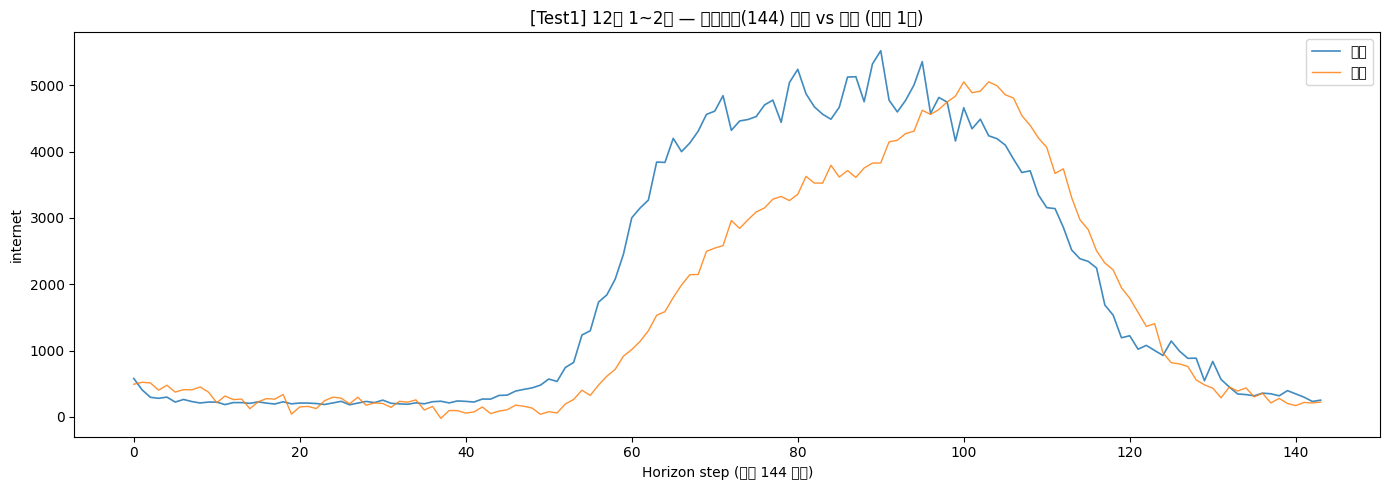

In [58]:
pred1_norm = model.predict(X_test1_k, verbose=0)

# inverse: (N, PRED_LEN) → flatten → inverse → reshape
y_true_inv = loader.inverse(y_test1.reshape(-1)).reshape(y_test1.shape)
y_pred_inv = loader.inverse(pred1_norm.reshape(-1)).reshape(pred1_norm.shape)

metrics_test1 = evaluate(y_true_inv, y_pred_inv, label="Test1 (12월 1~2주, Nov 학습 모델)")

sample_idx = 0
t = np.arange(PRED_LEN)
plt.figure(figsize=(14, 5))
plt.plot(t, y_true_inv[sample_idx], label="정답", alpha=0.85, linewidth=1.2)
plt.plot(t, y_pred_inv[sample_idx], label="예측", alpha=0.85, linewidth=1.0)
plt.xlabel("Horizon step (다음 {} 스텝)".format(PRED_LEN))
plt.ylabel(TARGET_COL)
plt.title("[Test1] 12월 1~2주 — 멀티스텝(144) 정답 vs 예측 (샘플 1개)")
plt.legend()
plt.tight_layout()
plt.show()

## Phase 3 — threshold 초과 시 재학습 (11월 + 12월 1~2주)

트리거 시 **초기 학습과 동일한 스케일러(11월 fit)** 를 유지한 채, 정규화된 시계열을 이어 붙여 재학습합니다.

In [59]:
do_retrain = should_retrain(metrics_test1, threshold=RMSE_THRESHOLD)

if do_retrain:
    combined_X = np.vstack([X_train_norm, X_test1_norm])
    combined_y = np.concatenate([y_train_norm, y_test1_norm])
    X_all, y_all = loader.make_windows(combined_X, combined_y, pred_len=PRED_LEN)
    X_all_k = X_all

    model_v2 = build_lstm_model()
    model_v2.compile(optimizer=keras.optimizers.Adam(learning_rate=LR * 0.5), loss="mse")
    model_v2 = train_model(model_v2, X_all_k, y_all, epochs=EPOCHS, verbose=1)
    path_v2 = MODEL_PATH.replace(".keras", "_v2.keras")
    model_v2.save(path_v2)
    print(f"💾 저장: {path_v2}")

    pred_v2 = model_v2.predict(X_test1_k, verbose=0)
    y_pred_v2 = loader.inverse(pred_v2.reshape(-1)).reshape(pred_v2.shape)
    metrics_v2 = evaluate(y_true_inv, y_pred_v2, label="Test1 재평가 (Nov+12월1~2주 재학습)")

    plt.figure(figsize=(14, 5))
    plt.plot(t, y_true_inv[sample_idx], label="정답", alpha=0.85)
    plt.plot(t, y_pred_v2[sample_idx], label="예측 v2", alpha=0.85)
    plt.title("[Test1] 재학습 후 (샘플 1개)")
    plt.legend()
    plt.tight_layout()
    plt.show()
else:
    print("재학습 생략.")


⚠️  RMSE 623.78 > 400.0 → 재학습 트리거
Epoch 1/30
 58/163 ━━━━━━━━━━━━━━━━━━━━ 9s 86ms/step - loss: 0.0346

KeyboardInterrupt: 

## (선택) Walk-forward — 1주 관측 → 학습 누적 → 다음 주 평가

1. **W1**: Phase 1에서 학습한 `model`(11월만)로 **12월 1주** RMSE (추가 학습 없음)  
2. **W2**: 11월 + 12월 1주 시계열을 이어 붙여 재학습한 모델로 **12월 2주** RMSE  

각 주는 파일 `timeseries_2`에서 `[start, end)` 로 자릅니다.

Walk-forward(week-to-week) shapes: X (1, 1008, 1) y (1, 1008)

📊 [Walk-forward (week2 | model=Nov만)] RMSE: 687.06  MAE: 461.52  MAPE: 37.51%
Epoch 1/30
104/104 ━━━━━━━━━━━━━━━━━━━━ 11s 98ms/step - loss: 0.0177
Epoch 2/30
104/104 ━━━━━━━━━━━━━━━━━━━━ 10s 99ms/step - loss: 0.0063
Epoch 3/30
104/104 ━━━━━━━━━━━━━━━━━━━━ 10s 97ms/step - loss: 0.0053
Epoch 4/30
104/104 ━━━━━━━━━━━━━━━━━━━━ 10s 98ms/step - loss: 0.0050
Epoch 5/30
104/104 ━━━━━━━━━━━━━━━━━━━━ 10s 98ms/step - loss: 0.0049
Epoch 6/30
104/104 ━━━━━━━━━━━━━━━━━━━━ 10s 98ms/step - loss: 0.0048
Epoch 7/30
104/104 ━━━━━━━━━━━━━━━━━━━━ 10s 98ms/step - loss: 0.0047
Epoch 8/30
104/104 ━━━━━━━━━━━━━━━━━━━━ 10s 97ms/step - loss: 0.0046
Epoch 9/30
104/104 ━━━━━━━━━━━━━━━━━━━━ 10s 97ms/step - loss: 0.0047
Epoch 10/30
104/104 ━━━━━━━━━━━━━━━━━━━━ 10s 97ms/step - loss: 0.0044
Epoch 11/30
104/104 ━━━━━━━━━━━━━━━━━━━━ 10s 97ms/step - loss: 0.0044
Epoch 12/30
104/104 ━━━━━━━━━━━━━━━━━━━━ 10s 96ms/step - loss: 0.0047
Epoch 13/30
104/104 ━━━━━━━━

/var/folders/fn/9knmnwzx6835y6s8x9rjv9vm0000gn/T/ipykernel_17832/1310290278.py:36: UserWarning: Glyph 50900 (\N{HANGUL SYLLABLE WEOL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/fn/9knmnwzx6835y6s8x9rjv9vm0000gn/T/ipykernel_17832/1310290278.py:36: UserWarning: Glyph 51452 (\N{HANGUL SYLLABLE JU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/fn/9knmnwzx6835y6s8x9rjv9vm0000gn/T/ipykernel_17832/1310290278.py:36: UserWarning: Glyph 51077 (\N{HANGUL SYLLABLE IB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/fn/9knmnwzx6835y6s8x9rjv9vm0000gn/T/ipykernel_17832/1310290278.py:36: UserWarning: Glyph 47141 (\N{HANGUL SYLLABLE RYEOG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/fn/9knmnwzx6835y6s8x9rjv9vm0000gn/T/ipykernel_17832/1310290278.py:36: UserWarning: Glyph 50696 (\N{HANGUL SYLLABLE YE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/fn/9knmnwzx6835y6s8x9rjv9vm0000gn/T/ipyker

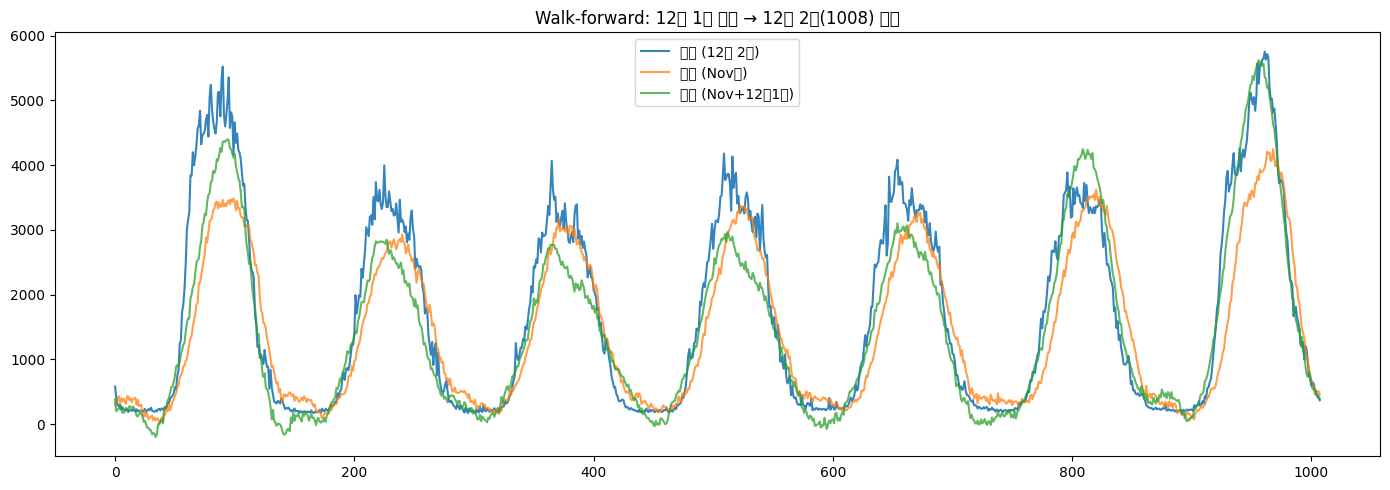

In [ ]:
df_w1 = slice_time(df_test_full, DEC_W1_START, DEC_W1_END)
df_w2 = slice_time(df_test_full, DEC_W2_START, DEC_W2_END)
w1_X, w1_y = loader.transform(df_w1)
w2_X, w2_y = loader.transform(df_w2)

# 7일 입력 → 다음 PRED_LEN 스텝 (w2의 앞 PRED_LEN 스텝을 정답으로 사용)
X_w12 = w1_X.reshape(1, SEQ_LEN, N_FEATURES)
y_w12 = w2_y[:PRED_LEN].reshape(1, PRED_LEN)

print("Walk-forward shapes:", "X", X_w12.shape, "y", y_w12.shape)

p1 = model.predict(X_w12, verbose=0)
y_w12_inv = loader.inverse(y_w12.reshape(-1)).reshape(y_w12.shape)
p1_inv = loader.inverse(p1.reshape(-1)).reshape(p1.shape)
evaluate(y_w12_inv, p1_inv, label="Walk-forward (Nov 모델 → 12월2주 앞 구간)")

combined_X = np.vstack([X_train_norm, w1_X])
combined_y = np.concatenate([y_train_norm, w1_y])
X_c1, y_c1 = loader.make_windows(combined_X, combined_y, pred_len=PRED_LEN)
X_c1_k = X_c1

m1 = build_lstm_model()
m1.compile(optimizer=keras.optimizers.Adam(learning_rate=LR * 0.5), loss="mse")
m1 = train_model(m1, X_c1_k, y_c1, epochs=EPOCHS, verbose=1)
p2 = m1.predict(X_w12, verbose=0)
p2_inv = loader.inverse(p2.reshape(-1)).reshape(p2.shape)
evaluate(y_w12_inv, p2_inv, label="Walk-forward (Nov+12월1주 재학습)")

plt.figure(figsize=(14, 5))
plt.plot(np.arange(PRED_LEN), y_w12_inv[0], label="정답", alpha=0.9)
plt.plot(np.arange(PRED_LEN), p1_inv[0], label="예측 (Nov만)", alpha=0.75)
plt.plot(np.arange(PRED_LEN), p2_inv[0], label="예측 (Nov+1주)", alpha=0.75)
plt.title("12월 1주 입력 → 다음 구간 예측 (멀티피처)")
plt.legend()
plt.tight_layout()
plt.show()

## 12월 전체를 1주(1008) 단위로 Walk-forward 평가 (3회 이상 가능)

- **week i 입력** → **week i+1 예측(1008개)** → 정답과 RMSE 평가
- 평가 후에는 **학습 데이터에 week i를 누적**해서 다음 주 예측 모델을 다시 학습(Expanding window)

> 전제: 12월 데이터가 `2013-12-01 00:00:00`부터 10분 간격으로 충분히 있고, 각 주가 정확히 1008 포인트여야 합니다. (부족하면 해당 주 pair는 스킵)

weeks:
  W1: 2013-12-01 00:00:00 → 2013-12-08 00:00:00  (10080 minutes)
  W2: 2013-12-08 00:00:00 → 2013-12-15 00:00:00  (10080 minutes)
  W3: 2013-12-15 00:00:00 → 2013-12-22 00:00:00  (10080 minutes)
  W4: 2013-12-22 00:00:00 → 2013-12-29 00:00:00  (10080 minutes)
  W5: 2013-12-29 00:00:00 → 2014-01-01 00:00:00  (4320 minutes)
Nov last-week(from train tail): 2013-11-23 23:00:00 → 2013-11-30 22:50:00 (points=1008)

📊 [Nov W4→Dec W1] RMSE: 959.43  MAE: 657.27  MAPE: 64.66%


/var/folders/fn/9knmnwzx6835y6s8x9rjv9vm0000gn/T/ipykernel_17832/3522515112.py:76: UserWarning: Glyph 51221 (\N{HANGUL SYLLABLE JEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/fn/9knmnwzx6835y6s8x9rjv9vm0000gn/T/ipykernel_17832/3522515112.py:76: UserWarning: Glyph 45813 (\N{HANGUL SYLLABLE DAB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/fn/9knmnwzx6835y6s8x9rjv9vm0000gn/T/ipykernel_17832/3522515112.py:76: UserWarning: Glyph 50696 (\N{HANGUL SYLLABLE YE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/fn/9knmnwzx6835y6s8x9rjv9vm0000gn/T/ipykernel_17832/3522515112.py:76: UserWarning: Glyph 52769 (\N{HANGUL SYLLABLE CEUG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/Users/baeseeun/Desktop/SKALA/practice/MLOps2/venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 51221 (\N{HANGUL SYLLABLE JEONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/

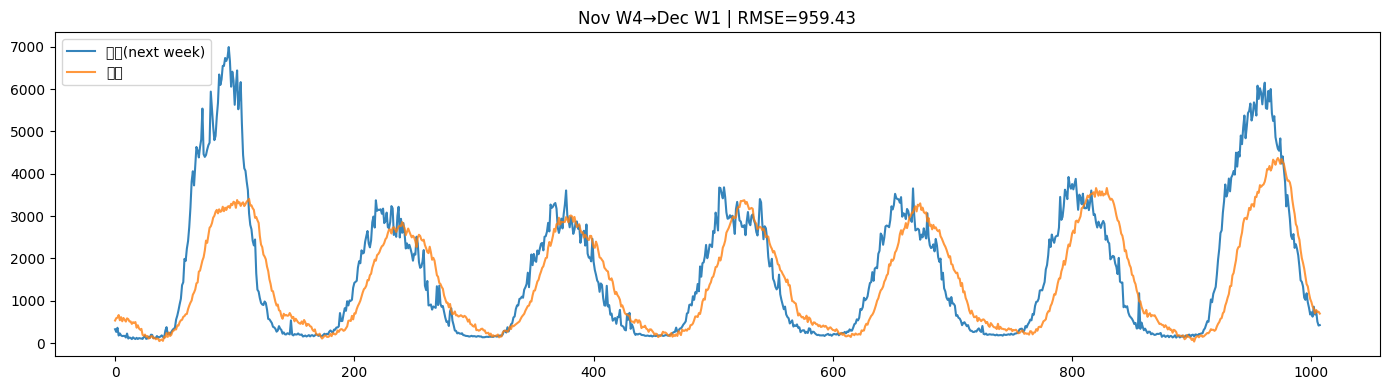


⚠️  RMSE 959.43 > 400.0 → 재학습 트리거

📊 [Dec W1→Dec W2] RMSE: 584.73  MAE: 393.35  MAPE: 31.70%


/var/folders/fn/9knmnwzx6835y6s8x9rjv9vm0000gn/T/ipykernel_17832/3522515112.py:76: UserWarning: Glyph 51221 (\N{HANGUL SYLLABLE JEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/fn/9knmnwzx6835y6s8x9rjv9vm0000gn/T/ipykernel_17832/3522515112.py:76: UserWarning: Glyph 45813 (\N{HANGUL SYLLABLE DAB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/fn/9knmnwzx6835y6s8x9rjv9vm0000gn/T/ipykernel_17832/3522515112.py:76: UserWarning: Glyph 50696 (\N{HANGUL SYLLABLE YE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/fn/9knmnwzx6835y6s8x9rjv9vm0000gn/T/ipykernel_17832/3522515112.py:76: UserWarning: Glyph 52769 (\N{HANGUL SYLLABLE CEUG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/Users/baeseeun/Desktop/SKALA/practice/MLOps2/venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 51221 (\N{HANGUL SYLLABLE JEONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/

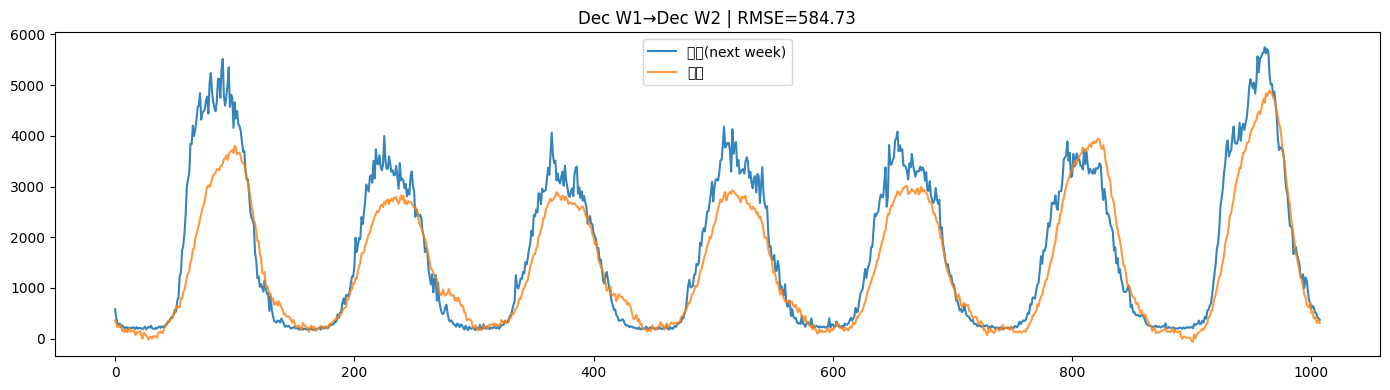


⚠️  RMSE 584.73 > 400.0 → 재학습 트리거


KeyboardInterrupt: 

In [50]:
# 12월을 1주(1008 step)로 나눠서 week→next_week 예측/평가
DEC_START = "2013-12-01 00:00:00"
DEC_END = "2014-01-01 00:00:00"  # 12월 말까지

week_edges = pd.date_range(start=pd.Timestamp(DEC_START), end=pd.Timestamp(DEC_END), freq="7D")
if week_edges[-1] != pd.Timestamp(DEC_END):
    week_edges = week_edges.append(pd.DatetimeIndex([pd.Timestamp(DEC_END)]))

weeks = [(week_edges[i], week_edges[i + 1]) for i in range(len(week_edges) - 1)]
print("weeks:")
for i, (a, b) in enumerate(weeks, 1):
    print(f"  W{i}: {a} → {b}  ({int((b-a).total_seconds()/60)} minutes)")

EXPECTED_WEEK_POINTS = SEQ_LEN  # 1008


def get_week_xy(df_full: pd.DataFrame, start: pd.Timestamp, end: pd.Timestamp):
    df_w = slice_time(df_full, str(start), str(end))
    return loader.transform(df_w)


if len(X_train_norm) < EXPECTED_WEEK_POINTS:
    raise ValueError(f"train X가 {EXPECTED_WEEK_POINTS}행보다 짧습니다: {len(X_train_norm)}")

nov_w4_X = X_train_norm[-EXPECTED_WEEK_POINTS:]
nov_w4_y = y_train_norm[-EXPECTED_WEEK_POINTS:]
nov_w4_start_dt = df_train["datetime"].iloc[-EXPECTED_WEEK_POINTS]
nov_w4_end_dt = df_train["datetime"].iloc[-1]
print(f"Nov last-week (train tail): {nov_w4_start_dt} → {nov_w4_end_dt} | X {nov_w4_X.shape}")

current_model = model
expanding_Xn = X_train_norm.copy()
expanding_yn = y_train_norm.copy()
results = []

prev_X = nov_w4_X
prev_y = nov_w4_y
prev_week_label = "Nov W4"

for i in range(len(weeks)):
    w_out = weeks[i]
    out_X, out_y = get_week_xy(df_test_full, w_out[0], w_out[1])

    if len(prev_X) != EXPECTED_WEEK_POINTS or len(out_X) != EXPECTED_WEEK_POINTS:
        print(f"SKIP {prev_week_label}→Dec W{i+1}: points mismatch (x={len(prev_X)}, out={len(out_X)})")
        prev_X, prev_y = out_X, out_y
        prev_week_label = f"Dec W{i+1}"
        continue

    if len(out_y) < PRED_LEN:
        print(f"SKIP {prev_week_label}→Dec W{i+1}: out_y shorter than PRED_LEN")
        prev_X, prev_y = out_X, out_y
        prev_week_label = f"Dec W{i+1}"
        continue

    X = prev_X.reshape(1, SEQ_LEN, N_FEATURES)
    y_true = out_y[:PRED_LEN].reshape(1, PRED_LEN)

    pred = current_model.predict(X, verbose=0)
    y_true_inv = loader.inverse(y_true.reshape(-1)).reshape(y_true.shape)
    y_pred_inv = loader.inverse(pred.reshape(-1)).reshape(pred.shape)

    label = f"{prev_week_label}→Dec W{i+1}"
    metrics = evaluate(y_true_inv, y_pred_inv, label=label)
    results.append({"pair": label, **metrics})

    plt.figure(figsize=(14, 4))
    plt.plot(np.arange(PRED_LEN), y_true_inv[0], label="정답", alpha=0.9)
    plt.plot(np.arange(PRED_LEN), y_pred_inv[0], label="예측", alpha=0.8)
    plt.title(f"{label} | RMSE={metrics['rmse']:.2f}")
    plt.legend()
    plt.tight_layout()
    plt.show()

    expanding_Xn = np.vstack([expanding_Xn, prev_X])
    expanding_yn = np.concatenate([expanding_yn, prev_y])

    if should_retrain(metrics, threshold=RMSE_THRESHOLD):
        X_tr, y_tr = loader.make_windows(expanding_Xn, expanding_yn, pred_len=PRED_LEN)
        current_model = build_lstm_model()
        current_model.compile(optimizer=keras.optimizers.Adam(learning_rate=LR * 0.5), loss="mse")
        current_model = train_model(current_model, X_tr, y_tr, epochs=EPOCHS, verbose=0)
    else:
        print("→ keep current_model (no retrain)")

    prev_X, prev_y = out_X, out_y
    prev_week_label = f"Dec W{i+1}"

print("\nSummary:")
if results:
    for r in results:
        print(r)
else:
    print("No weekly evaluations were run (week length mismatch?).")